In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(
    r"C:\Users\workk\OneDrive\Desktop\churn prediction project\WA_Fn-UseC_-Telco-Customer-Churn (1).csv")

In [6]:
df.drop(
    "customerID",
    axis=1,
    inplace=True
)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors='coerce'
)

df.dropna(inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [7]:
df["Charges_Per_Tenure"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

df["HighValueCustomer"] = (
    df["MonthlyCharges"] > 80
).astype(int)

df["LongTermCustomer"] = (
    df["tenure"] > 24
).astype(int)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Charges_Per_Tenure,HighValueCustomer,LongTermCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,14.925000,0,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,No,53.985714,0,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,36.050000,0,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.016304,0,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,50.550000,0,0


In [8]:
df["Churn"] = df["Churn"].map({

    "Yes":1,

    "No":0
})

In [9]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

In [10]:
X = df.drop(
    "Churn",
    axis=1
)

y = df["Churn"]

In [11]:
categorical_cols = X.select_dtypes(
    include=['object']
).columns

numerical_cols = X.select_dtypes(
    exclude=['object']
).columns

In [12]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [13]:
numeric_transformer = Pipeline([

    (
        'imputer',
        SimpleImputer(strategy='median')
    ),

    (
        'scaler',
        StandardScaler()
    )
])

In [14]:
categorical_transformer = Pipeline([

    (
        'imputer',
        SimpleImputer(strategy='most_frequent')
    ),

    (
        'onehot',
        OneHotEncoder(handle_unknown='ignore')
    )
])

In [15]:
preprocessor = ColumnTransformer([

    (
        'num',
        numeric_transformer,
        numerical_cols
    ),

    (
        'cat',
        categorical_transformer,
        categorical_cols
    )
])

In [16]:
from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import SMOTE

from catboost import CatBoostClassifier

import joblib

In [17]:
deployment_pipeline = ImbPipeline([

    (
        'preprocessor',
        preprocessor
    ),

    (
        'smote',
        SMOTE(random_state=42)
    ),

    (
        'model',

        CatBoostClassifier(

            iterations=1000,

            learning_rate=0.02,

            depth=6,

            loss_function='Logloss',

            eval_metric='AUC',

            random_seed=42,

            verbose=0
        )
    )
])

In [18]:
deployment_pipeline.fit(
    X_train,
    y_train
)

print("PIPELINE TRAINED SUCCESSFULLY")

PIPELINE TRAINED SUCCESSFULLY


In [19]:
preds = deployment_pipeline.predict(
    X_test
)

probs = deployment_pipeline.predict_proba(
    X_test
)[:,1]

In [20]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        preds
    )
)

Accuracy: 0.7768301350390903


In [21]:
print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        probs
    )
)

ROC-AUC: 0.8284149794741446


In [22]:
print(

    classification_report(

        y_test,

        preds
    )
)

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [23]:
from sklearn.metrics import confusion_matrix

In [24]:
cm = confusion_matrix(
    y_test,
    preds
)

cm

array([[869, 164],
       [150, 224]])

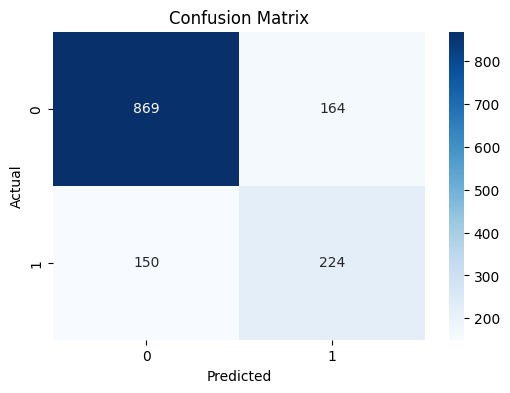

In [25]:
plt.figure(figsize=(6,4))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [26]:
from sklearn.metrics import roc_curve

In [27]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    probs
)

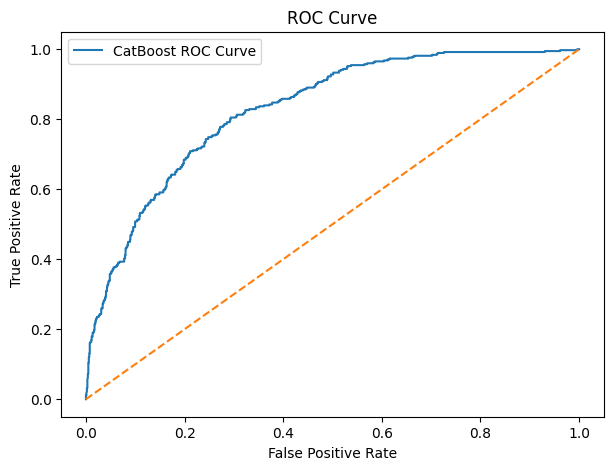

In [28]:
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label='CatBoost ROC Curve'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.show()

In [29]:
import joblib

In [30]:
joblib.dump(

    deployment_pipeline,

    "churn_pipeline.pkl"
)

print("PIPELINE SAVED SUCCESSFULLY")

PIPELINE SAVED SUCCESSFULLY


In [31]:
loaded_pipeline = joblib.load(
    "churn_pipeline.pkl"
)

print("PIPELINE LOADED")

PIPELINE LOADED


In [32]:
sample = X_test.iloc[[0]]

sample

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Charges_Per_Tenure,HighValueCustomer,LongTermCustomer
974,Female,0,Yes,Yes,59,Yes,No,DSL,No,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),75.95,4542.35,75.705833,0,1


In [33]:
loaded_pipeline.predict(sample)

array([0])